# NYC Airbnb Market Analysis

## Project Objective
The objective of this project is to explore the structure of the Airbnb market in New York City and identify patterns in listing distribution, room type composition, review activity, and annual availability.

This project also includes a data quality validation step, since several variables (especially price) show signs of limited reliability.

## Dataset
- Source: Airbnb Open Data
- Unit of analysis: individual Airbnb listings

## Workflow
This notebook follows the project methodology:
1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis
4. Insights
5. Export of cleaned dataset

# 1. Data Understanding

The goal of this section is to understand the structure, completeness, and initial quality of the dataset before making any transformations.

In [190]:
# Libraries

import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Upload from Kaggle

path = kagglehub.dataset_download("arianazmoudeh/airbnbopendata")

files = os.listdir(path)
print("Archivos:", files)


Archivos: ['Airbnb_Open_Data.csv']


In [191]:
# CSV file reading

df = pd.read_csv(path + "/Airbnb_Open_Data.csv")

C:\Users\galoa\AppData\Local\Temp\ipykernel_90876\3989297750.py:3: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path + "/Airbnb_Open_Data.csv")


In [192]:
# Overview

print("Shape:", df.shape)

Shape: (102599, 26)


In [193]:
# Info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  str    
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  str    
 4   host name                       102193 non-null  str    
 5   neighbourhood group             102570 non-null  str    
 6   neighbourhood                   102583 non-null  str    
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  str    
 10  country code                    102468 non-null  str    
 11  instant_bookable                102494 non-null  object 
 12  cancellation_policy        

In [194]:
# Columns name

print("\nColumns:")
print(df.columns.to_list())


Columns:
['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules', 'license']


In [195]:
# Data type

print ("\nData type:")
display(df.dtypes)


Data type:


id                                  int64
NAME                                  str
host id                             int64
host_identity_verified                str
host name                             str
neighbourhood group                   str
neighbourhood                         str
lat                               float64
long                              float64
country                               str
country code                          str
instant_bookable                   object
cancellation_policy                   str
room type                             str
Construction year                 float64
price                                 str
service fee                           str
minimum nights                    float64
number of reviews                 float64
last review                           str
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availability 365                  

In [196]:
# Stadistical summary

display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,102599.0,NaN,NaN,NaN,29146234.52213,16257505.607309,1001254.0,15085814.5,29136603.0,43201198.0,57367417.0
NAME,102349,61281,Home away from home,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host id,102599.0,NaN,NaN,NaN,49254111474.328667,28538996644.374882,123600518.0,24583328475.0,49117739352.0,73996495817.0,98763129024.0
host_identity_verified,102310,2,unconfirmed,51200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host name,102193,13190,Michael,881,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood group,102570,7,Manhattan,43792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,102583,224,Bedford-Stuyvesant,7937,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,102591.0,NaN,NaN,NaN,40.728094,0.055857,40.49979,40.68874,40.72229,40.76276,40.91697
long,102591.0,NaN,NaN,NaN,-73.949644,0.049521,-74.24984,-73.98258,-73.95444,-73.93235,-73.70522
country,102067,1,United States,102067,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [197]:
# Nulls per column

nulls = df.isna().sum().sort_values(ascending=False)
nulls_percent = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)

nulls_df = pd.DataFrame({
    "null_count": nulls,
    "null_percent": nulls_percent
})

display(nulls_df)

# Unique values ​​per column
unique_df = pd.DataFrame({
    "unique_values": df.nunique()
}).sort_values(by="unique_values", ascending=False)

display(unique_df)

,null_count,null_percent
license,102597,99.998051
house_rules,52131,50.810437
last review,15893,15.490404
reviews per month,15879,15.476759
country,532,0.518524
availability 365,448,0.436651
minimum nights,409,0.398639
host name,406,0.395715
review rate number,326,0.317742
calculated host listings count,319,0.310919


,unique_values
id,102058
host id,102057
NAME,61281
lat,21991
long,17774
host name,13190
last review,2477
house_rules,1976
price,1151
reviews per month,1016


**Initial Findings**

The dataset contains 102,599 records and 26 columns related to Airbnb listings, including variables such as location, price, room type, review activity, availability, and host characteristics.
Upon initial inspection, several columns with improvable data types were identified, particularly price, service fee, and last review, as well as columns with a high proportion of missing values such as license and house_rules.
The variables with the greatest analytical potential for the project are those related to price, location, accommodation type, reviews, and availability.


# 2. Data Cleaning

The purpose of this section is to improve data consistency and remove records that could distort the analysis.

In [198]:
# Standardize column names

df_clean = df.copy()

df_clean.columns = df_clean.columns.str.lower().str.replace(" ", "_")

print(df_clean.columns.tolist())

['id', 'name', 'host_id', 'host_identity_verified', 'host_name', 'neighbourhood_group', 'neighbourhood', 'lat', 'long', 'country', 'country_code', 'instant_bookable', 'cancellation_policy', 'room_type', 'construction_year', 'price', 'service_fee', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'review_rate_number', 'calculated_host_listings_count', 'availability_365', 'house_rules', 'license']


In [199]:
# Drop irrelevant columns

columns_to_drop = ["license", "house_rules", "country", "country_code"]

df_clean = df_clean.drop(columns=columns_to_drop)

print(df_clean.columns.tolist())

['id', 'name', 'host_id', 'host_identity_verified', 'host_name', 'neighbourhood_group', 'neighbourhood', 'lat', 'long', 'instant_bookable', 'cancellation_policy', 'room_type', 'construction_year', 'price', 'service_fee', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'review_rate_number', 'calculated_host_listings_count', 'availability_365']


These columns were removed because they either contained an extremely high percentage of missing values or did not provide analytical value for the business questions of the project.

In [200]:
# Convert price and service_fee

df_clean["price"] = df_clean["price"].replace("[$,]", "", regex=True)
df_clean["service_fee"] = df_clean["service_fee"].replace("[$,]", "", regex=True)

df_clean["price"] = pd.to_numeric(df_clean["price"], errors="coerce")
df_clean["service_fee"] = pd.to_numeric(df_clean["service_fee"], errors="coerce")

print(df_clean[["price", "service_fee"]].dtypes)

price          float64
service_fee    float64
dtype: object


Price-related variables must be numeric to enable aggregation, filtering, and visualization.

In [201]:
# Convert last review to datetime

df_clean["last_review"] = pd.to_datetime(df_clean["last_review"], errors="coerce")

print(df_clean['last_review'].dtype)

datetime64[us]


Converting to datetime allows time-based analysis and proper handling of missing values.

In [202]:
# Convert categorical variables to category type

categorical_cols = [
    "host_identity_verified",
    "instant_bookable",
    "cancellation_policy",
    "room_type",
    "neighbourhood_group"
]

for col in categorical_cols:
    df_clean[col] = df_clean[col].astype("category")

Categorical types improve memory efficiency and make grouping operations clearer.

In [203]:
# Missing values

print(df_clean["price"].isna().sum())
print(df_clean["service_fee"].isna().sum())
print(df_clean["neighbourhood_group"].isna().sum())

df_clean = df_clean.dropna(subset=["price"])
df_clean = df_clean.dropna(subset=["neighbourhood_group"])

247
273
29


Price is a core variable. Rows without price cannot contribute to the analysis.

In [204]:
# Fill missing values with 0

df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0)

Missing last_review values likely indicate listings with no reviews.

In [205]:
# number_of_reviews

df_clean["number_of_reviews"] = df_clean["number_of_reviews"].fillna(0)

In [206]:
df_clean["availability_365"] = df_clean["availability_365"].fillna(0)
df_clean["minimum_nights"] = df_clean["minimum_nights"].fillna(df_clean["minimum_nights"].median())

In [207]:
# Check duplicates

duplicates = df_clean.duplicated().sum()
print("Duplicate rows:", duplicates)

df_clean = df_clean.drop_duplicates()

Duplicate rows: 541


In [208]:
# Check negative or absurd values

print(df_clean["price"].describe())
print(df_clean["minimum_nights"].describe())

count    101783.000000
mean        625.346502
std         331.672560
min          50.000000
25%         340.000000
50%         624.000000
75%         913.000000
max        1200.000000
Name: price, dtype: float64
count    101783.000000
mean          8.095438
std          30.561838
min       -1223.000000
25%           2.000000
50%           3.000000
75%           5.000000
max        5645.000000
Name: minimum_nights, dtype: float64


In [209]:
# Remove invalid negative values

df_clean = df_clean[df_clean["minimum_nights"] >= 0]

# Remove extreme unrealistic values

df_clean = df_clean[df_clean["minimum_nights"] <= 365]

Extremely high values in minimum_nights were filtered using a business rule threshold of 365 nights to keep the analysis focused on realistic short-term rental behavior.

In [210]:
# Remove invalid availability values

df_clean = df_clean[df_clean["availability_365"] >= 0]

Invalid negative values in minimum_nights and availability_365 were removed because they are not logically possible in the Airbnb business context.

In [211]:
# Remove future dates while keeping NaN values

df_clean = df_clean[
    (df_clean["last_review"].isna()) | (df_clean["last_review"].dt.year <= 2025)
]

Future dates in last_review were removed because they represent data quality issues and missing values in last_review were preserved because they represent listings without reviews, not data errors.

In [212]:
# Check

print(df_clean["minimum_nights"].describe())
print(df_clean["availability_365"].describe())
print(df_clean["last_review"].describe())
print("Final shape:", df_clean.shape)

count    101302.000000
mean          7.818000
std          16.971671
min           1.000000
25%           2.000000
50%           3.000000
75%           5.000000
max         365.000000
Name: minimum_nights, dtype: float64
count    101302.000000
mean        141.023810
std         135.397866
min           0.000000
25%           3.000000
50%          96.000000
75%         268.000000
max        3677.000000
Name: availability_365, dtype: float64
count                         85600
mean     2019-06-12 14:35:39.476635
min             2012-07-11 00:00:00
25%             2018-10-28 00:00:00
50%             2019-06-14 00:00:00
75%             2019-07-05 00:00:00
max             2025-06-26 00:00:00
Name: last_review, dtype: object
Final shape: (101302, 22)


In [213]:
# Remove unrealistic availability values > 365 days

df_clean = df_clean[df_clean["availability_365"] <= 365]

Removed as they are not logically possible within a yearly calendar.

In [214]:
# Ensure last_review is datetime

df_clean["last_review"] = pd.to_datetime(df_clean["last_review"], errors="coerce")

In [215]:
print(df_clean["last_review"].dtype)

datetime64[us]


In [235]:
# Check unique values in neighbourhood_group

print(df_clean["neighbourhood_group"].value_counts(dropna=False))

neighbourhood_group
Manhattan        41875
Brooklyn         40201
Queens           12910
Bronx             2649
Staten Island      926
Name: count, dtype: int64


In [217]:
# Standardize neighbourhood_group labels
df_clean["neighbourhood_group"] = df_clean["neighbourhood_group"].replace({
    "brookln": "Brooklyn",
    "manhatan": "Manhattan"
})

In [218]:
# Remove unused categories after replacement

df_clean["neighbourhood_group"] = df_clean["neighbourhood_group"].cat.remove_unused_categories()

In [234]:
# Recheck category counts

print(df_clean["neighbourhood_group"].value_counts(dropna=False))

neighbourhood_group
Manhattan        41875
Brooklyn         40201
Queens           12910
Bronx             2649
Staten Island      926
Name: count, dtype: int64


# 3. Exploratory Data Analysis

This section explores the cleaned dataset to identify descriptive patterns in market structure.

The analysis focuses on variables that are most relevant for understanding listing concentration, accommodation type, review activity, availability, and price behavior.

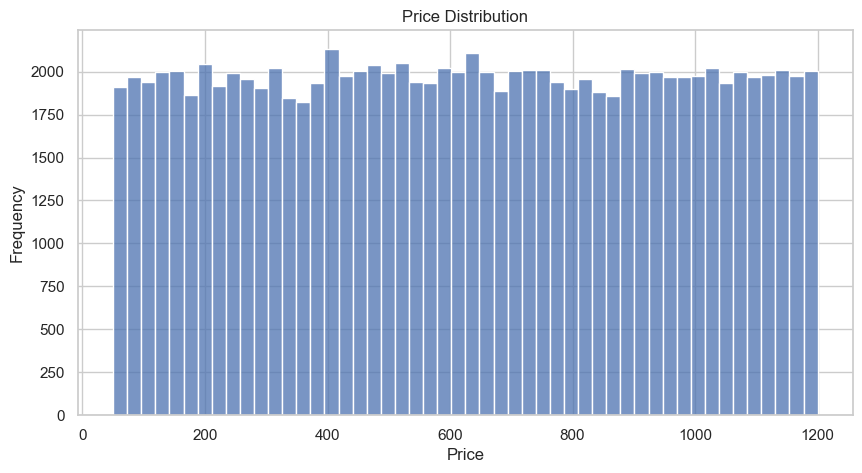

In [236]:
# Price Validation

sns.set(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["price"], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

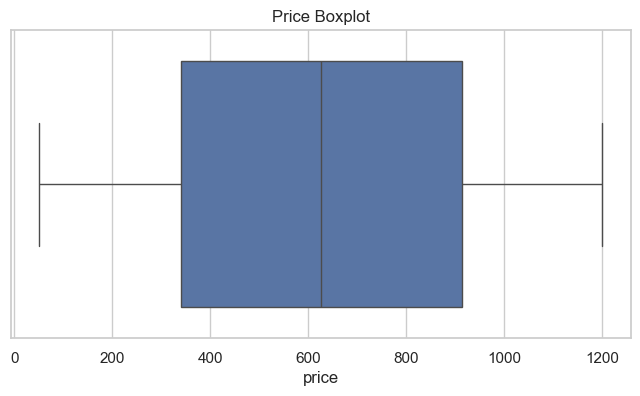

In [221]:
# Boxplot price

plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean["price"])
plt.title("Price Boxplot")
plt.show()

**The price variable shows a very uniform distribution across categories, which is not consistent with real Airbnb market behavior. This suggests that the dataset may contain synthetic or non-representative pricing patterns. Therefore, insights related to price segmentation should be interpreted with caution.**

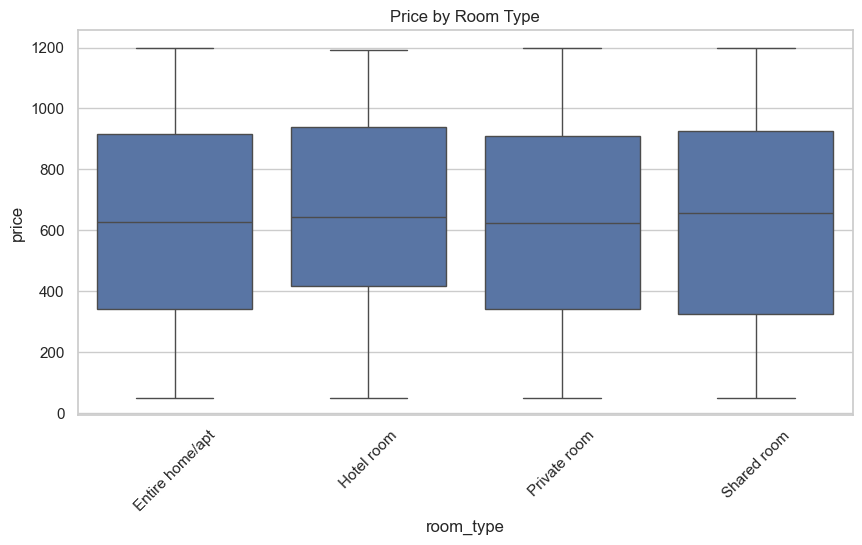

In [222]:
# Price by room type

plt.figure(figsize=(10, 5))
sns.boxplot(x="room_type", y="price", data=df_clean)
plt.title("Price by Room Type")
plt.xticks(rotation=45)
plt.show()

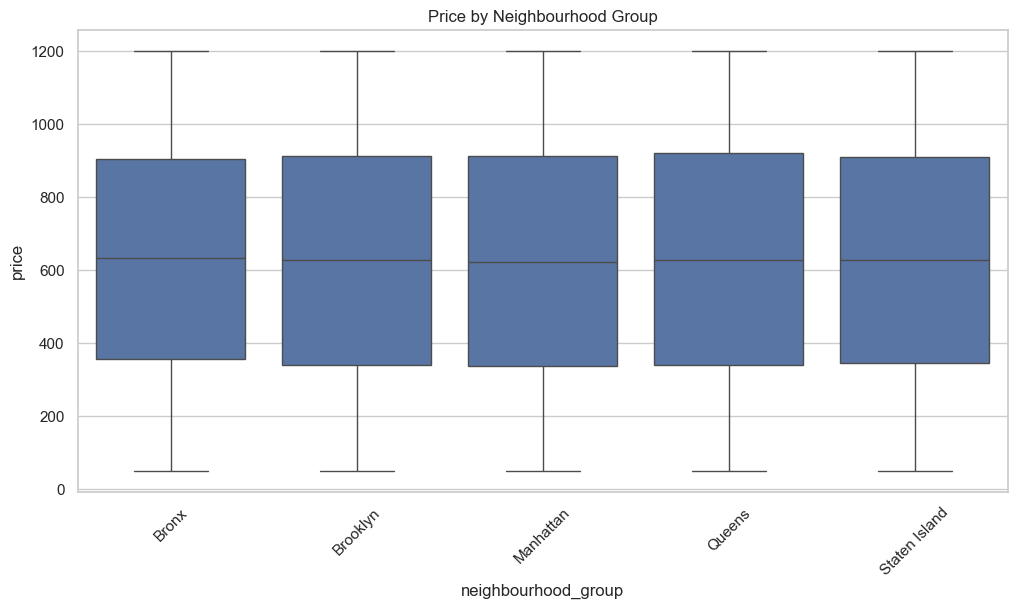

In [238]:
# Price by neighbourhood group
plt.figure(figsize=(12, 6))
sns.boxplot(x="neighbourhood_group", y="price", data=df_clean)
plt.title("Price by Neighbourhood Group")
plt.xticks(rotation=45)
plt.show()


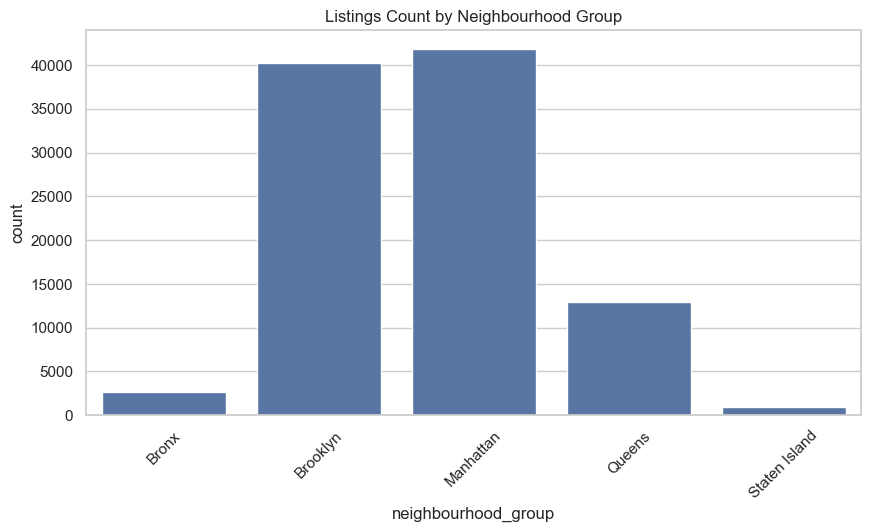

In [237]:
# Listings count by neighbourhood group
plt.figure(figsize=(10, 5))
sns.countplot(x="neighbourhood_group", data=df_clean)
plt.title("Listings Count by Neighbourhood Group")
plt.xticks(rotation=45)
plt.show()

Although the number of listings varies significantly across boroughs (with Manhattan and Brooklyn having the highest concentration), the price distribution appears remarkably similar in all of them. This uniformity suggests that the dataset may not accurately reflect real-world market differences, where higher prices are typically expected in areas like Manhattan. Therefore, this could indicate sampling bias or limitations in the dataset’s representativeness.

# 4. Insights

Based on the exploratory analysis, findings are separated into two confidence levels:

- **High-confidence insights**, supported by stable descriptive patterns
- **Cautionary insights**, affected by potential dataset limitations

### 4.1 High-Confidence Insights

#### Market supply is highly concentrated in Manhattan and Brooklyn

The distribution of listings shows a strong concentration in Manhattan and Brooklyn, indicating that these two boroughs dominate the supply side of the dataset.

In [224]:
# Listings count by neighbourhood group

neighbourhood_counts = (
    df_clean["neighbourhood_group"]
    .value_counts(dropna=False)
    .reset_index()
)

neighbourhood_counts.columns = ["neighbourhood_group", "listings_count"]
display(neighbourhood_counts)

,neighbourhood_group,listings_count
0,Manhattan,41875
1,Brooklyn,40201
2,Queens,12910
3,Bronx,2649
4,Staten Island,926


**Market supply is highly concentrated**

Manhattan (41,875 listings) and Brooklyn (40,201 listings) dominate the dataset, representing the vast majority of listings. Other boroughs such as Queens (12,910), Bronx (2,649), and Staten Island (926) have significantly fewer listings. The Airbnb market in New York is highly concentrated in Manhattan and Brooklyn, suggesting these areas are the primary hubs for tourism and short-term rental activity.

**Queens represents a secondary market**

Queens represents a secondary market in the context of Airbnb listings. While it has a notable number of listings, it significantly lags behind Manhattan and Brooklyn in terms of volume. This suggests that Queens serves as an alternative for travelers who may be seeking less density or more affordable pricing options, positioning it as a secondary market with distinct appeal compared to the more central areas.

In [225]:
# Listings count by room type

room_type_counts = (
    df_clean["room_type"]
    .value_counts(dropna=False)
    .reset_index()
)

room_type_counts.columns = ["room_type", "listings_count"]
display(room_type_counts)

,room_type,listings_count
0,Entire home/apt,51481
1,Private room,44817
2,Shared room,2148
3,Hotel room,115


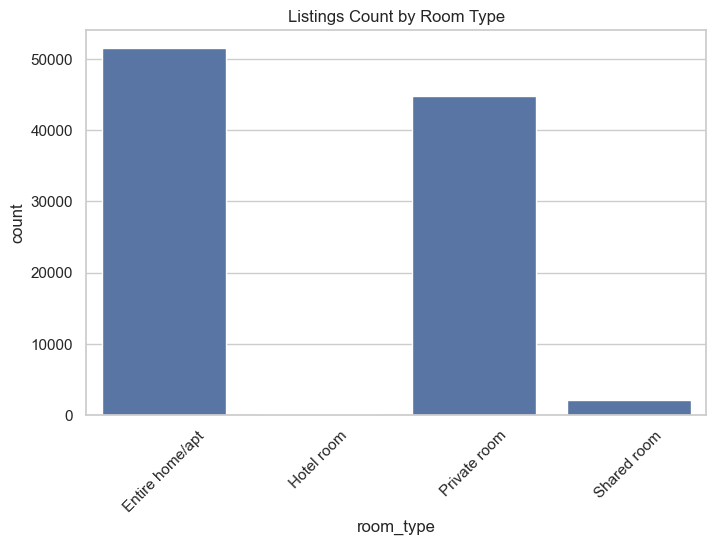

In [226]:
# Listings count by room type

plt.figure(figsize=(8, 5)) 
sns.countplot(x="room_type", data=df_clean) 
plt.title("Listings Count by Room Type") 
plt.xticks(rotation=45) 
plt.show()

**Market is dominated by entire homes and private rooms**

The market is predominantly dominated by entire homes and private rooms. Specifically, there are approximately 51,000 listings for entire homes or apartments, followed by around 44,800 listings for private rooms. In contrast, shared rooms and hotel rooms account for a significantly smaller portion, with only about 2,100 and 115 listings, respectively. From a business perspective, this indicates that the Airbnb market is primarily driven by entire properties and private rooms, while shared and hotel-type accommodations remain a very small segment.

In [227]:
# Average number of reviews by neighbourhood group

reviews_by_neighbourhood = (
    df_clean.groupby("neighbourhood_group", dropna=False)["number_of_reviews"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

reviews_by_neighbourhood.columns = ["neighbourhood_group", "avg_number_of_reviews"]
display(reviews_by_neighbourhood)

,neighbourhood_group,avg_number_of_reviews
0,Staten Island,35.285097
1,Queens,33.428428
2,Bronx,31.179313
3,Brooklyn,28.241487
4,Manhattan,23.830448


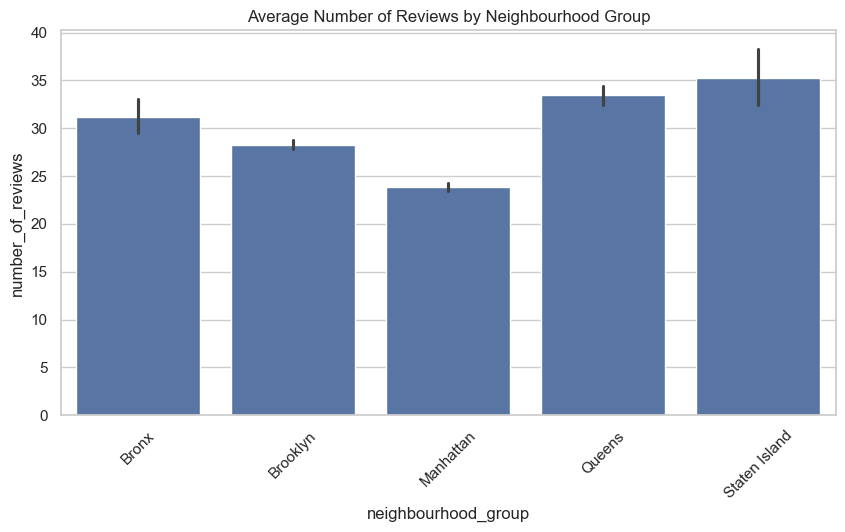

In [228]:
# Average number of reviews by neighbourhood group

plt.figure(figsize=(10, 5))
sns.barplot(x="neighbourhood_group", y="number_of_reviews", data=df_clean, estimator="mean")
plt.title("Average Number of Reviews by Neighbourhood Group")
plt.xticks(rotation=45)
plt.show()

**Review activity varies across boroughs**

Review activity varies across boroughs, with Staten Island (around 35) and Queens (around 33) showing the highest average number of reviews per listing, while Manhattan has the lowest (around 23). From a business perspective, this may suggest that listings in less saturated boroughs accumulate more reviews over time, possibly due to lower competition or longer listing lifespans. However, it is important to note that a higher number of reviews does not necessarily indicate better quality, but simply that these listings tend to gather more feedback.

In [229]:
# Average availability by neighbourhood group

availability_by_neighbourhood = (
    df_clean.groupby("neighbourhood_group", dropna=False)["availability_365"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

availability_by_neighbourhood.columns = ["neighbourhood_group", "avg_availability_365"]
display(availability_by_neighbourhood)

,neighbourhood_group,avg_availability_365
0,Staten Island,195.816415
1,Bronx,175.974707
2,Queens,157.720449
3,Manhattan,133.871690
4,Brooklyn,122.104997


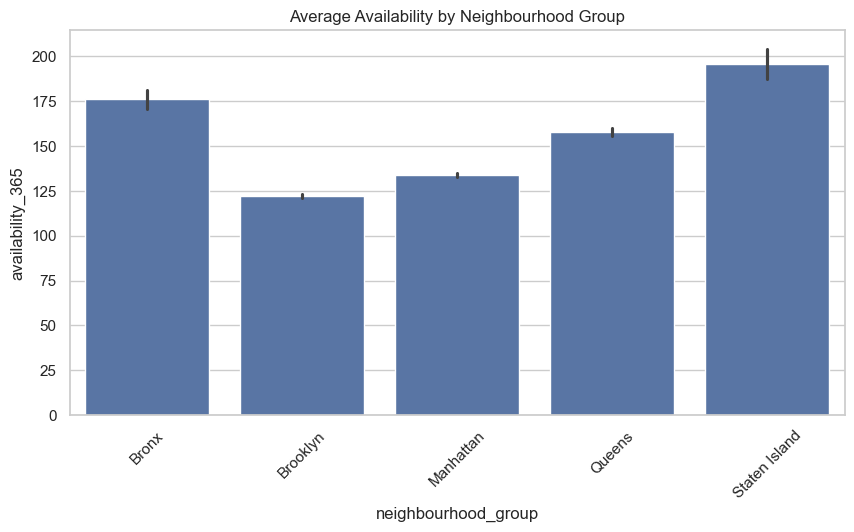

In [230]:
# Average availability by neighbourhood group

plt.figure(figsize=(10, 5))
sns.barplot(x="neighbourhood_group", y="availability_365", data=df_clean, estimator="mean")
plt.title("Average Availability by Neighbourhood Group")
plt.xticks(rotation=45)
plt.show()

**Availability differs significantly by borough**

Availability differs significantly by borough, with Staten Island (around 195 days) and Bronx (around 175 days) showing the highest availability, while Brooklyn (around 122 days) and Manhattan (around 133 days) have the lowest. From a business perspective, this pattern suggests that listings in more central boroughs tend to have lower availability, which may reflect higher demand or more frequent bookings compared to less central areas.

### 4.2 Cautionary Insights

#### Price patterns are not reliable enough for strong business interpretation

Although price summaries can be calculated, the variable shows suspiciously limited differentiation across boroughs and room types.

Because this behavior does not align with realistic market expectations, price-related findings are treated as analytically limited.

In [231]:
# Price summary by room type

price_by_room_type = (
    df_clean.groupby("room_type", dropna=False)["price"]
    .agg(["mean", "median", "min", "max"])
    .sort_values(by="mean", ascending=False)
    .reset_index()
)

display(price_by_room_type)

,room_type,mean,median,min,max
0,Hotel room,666.391304,643.0,50.0,1193.0
1,Shared room,634.595438,655.0,50.0,1199.0
2,Entire home/apt,626.142286,626.0,50.0,1200.0
3,Private room,624.766004,623.0,50.0,1200.0


In [232]:
# Price summary by neighbourhood group

price_by_neighbourhood = (
    df_clean.groupby("neighbourhood_group", dropna=False)["price"]
    .agg(["mean", "median", "min", "max"])
    .sort_values(by="mean", ascending=False)
    .reset_index()
)

display(price_by_neighbourhood)

,neighbourhood_group,mean,median,min,max
0,Queens,629.869558,628.0,50.0,1200.0
1,Bronx,628.055115,634.0,50.0,1200.0
2,Brooklyn,626.643516,627.0,50.0,1200.0
3,Staten Island,624.930886,627.5,50.0,1200.0
4,Manhattan,623.488931,624.0,50.0,1200.0


**Price patterns are not reliable**

Price patterns are not reliable across the dataset, as average prices remain almost identical (around 620–660) regardless of room type or borough, including Manhattan, Brooklyn, and Queens. From a business perspective, this lack of variation suggests that the dataset does not capture realistic price differentiation between market segments. As a result, there is an important caution: prices may be artificially distributed, and any pricing insights derived from this data should not be used to support strong or strategic business conclusions.

# 5. Final Conclusion

This project provides a structured descriptive analysis of the NYC Airbnb market while explicitly validating data quality before drawing conclusions.

The strongest findings relate to:
- listing concentration
- room type composition
- review activity
- availability patterns

However, pricing behavior appears unusually uniform and should not be used for strong business recommendations in this dataset.

This project demonstrates both technical analysis skills and critical judgment when working with imperfect real-world data.

# 6. Export Cleaned Dataset

The cleaned dataset is exported for visualization and dashboard development.

In [233]:
df_clean.to_csv('Airbnb_Open_Data_Cleaned.csv')